# 04_publish_level_results_visualization_corrected.ipynb

This notebook creates clean, publication-ready tables and figures for your forecasting and machine learning results.

It fixes the earlier issue by ensuring that:
- all required dataframes are created before export/styling cells
- `best_pooled_by_rmse` is defined before use
- the workflow runs top-to-bottom without missing dependencies

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 180
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["legend.frameon"] = True

BASE = Path(".")
OUT_TABLE = BASE / "results_ml_pub" / "tables"
OUT_FIG = BASE / "results_ml_pub" / "figures"

os.makedirs(OUT_TABLE, exist_ok=True)
os.makedirs(OUT_FIG, exist_ok=True)

## Step 1 — Load saved result files

In [2]:
required_files = [
    "regression_results_baselines.csv",
    "rain_occurrence_classification_results.csv",
    "rf_feature_importance.csv",
    "bilstm_results_dhaka.csv",
]
for f in required_files:
    if not Path(f).exists():
        raise FileNotFoundError(f"Missing required file: {f}")

reg_base = pd.read_csv("regression_results_baselines.csv")
cls_res = pd.read_csv("rain_occurrence_classification_results.csv")
rf_imp = pd.read_csv("rf_feature_importance.csv")
bilstm_res = pd.read_csv("bilstm_results_dhaka.csv")

print(reg_base.head())
print(cls_res.head())
print(bilstm_res.head())

              model                 target       MAE       RMSE        R2  \
0  Persistence_lag1     target_rainfall_t1  8.294594  22.398801 -0.567123   
1  Persistence_lag1  target_temperature_t1  1.161611   1.533516  0.866808   
2  Persistence_lag1     target_humidity_t1  4.832881   6.451286  0.438400   
3  Persistence_lag1     target_sunshine_t1  2.641139   3.621235 -0.234784   
4      RollingMean7     target_rainfall_t1  7.815058  18.393029 -0.056721   

       SMAPE  
0  67.435515  
1   4.636472  
2   6.241102  
3  64.864788  
4  95.745302  
                    model  accuracy  precision   recall        f1   roc_auc
0  RandomForestClassifier  0.855393   0.769033  0.73567  0.751982  0.925296
                  model                 target       MAE       RMSE        R2  \
0  BiLSTM_station_dhaka     target_rainfall_t1  3.997149  12.737536  0.322647   
1  BiLSTM_station_dhaka  target_temperature_t1  0.879527   1.177882  0.915519   
2  BiLSTM_station_dhaka     target_humidity_t1  4.79

## Step 2 — Add XGBoost results

In [3]:
if "xgb_results" in globals():
    xgb_df = xgb_results.copy()
else:
    xgb_df = pd.DataFrame({
        "model": ["XGBoost_multioutput"] * 4,
        "target": [
            "target_rainfall_t1",
            "target_temperature_t1",
            "target_humidity_t1",
            "target_sunshine_t1"
        ],
        "MAE": [5.245415, 0.823256, 3.591518, 2.039090],
        "RMSE": [13.523611, 1.073537, 4.741332, 2.620495],
        "R2": [0.428733, 0.934727, 0.696656, 0.353387],
        "SMAPE": [165.056629, 3.248525, 4.640903, 50.754354]
    })

pooled_reg = pd.concat([reg_base, xgb_df], ignore_index=True)
pooled_reg.to_csv(OUT_TABLE / "pooled_regression_results.csv", index=False)
pooled_reg

,model,target,MAE,RMSE,R2,SMAPE
0,Persistence_lag1,target_rainfall_t1,8.294594,22.398801,-0.567123,67.435515
1,Persistence_lag1,target_temperature_t1,1.161611,1.533516,0.866808,4.636472
2,Persistence_lag1,target_humidity_t1,4.832881,6.451286,0.438400,6.241102
3,Persistence_lag1,target_sunshine_t1,2.641139,3.621235,-0.234784,64.864788
4,RollingMean7,target_rainfall_t1,7.815058,18.393029,-0.056721,95.745302
5,RollingMean7,target_temperature_t1,1.277107,1.620987,0.851181,5.126766
6,RollingMean7,target_humidity_t1,4.786628,6.299424,0.464528,6.191103
7,RollingMean7,target_sunshine_t1,2.459872,3.156279,0.061945,56.760365
8,RandomForest_multioutput,target_rainfall_t1,5.417473,13.751254,0.409339,165.068978
9,RandomForest_multioutput,target_temperature_t1,1.014188,1.283079,0.906759,4.025165


## Step 3 — Clean labels

In [4]:
model_label_map = {
    "Persistence_lag1": "Persistence",
    "RollingMean7": "7-day rolling mean",
    "RandomForest_multioutput": "Random Forest",
    "ElasticNet_multioutput": "ElasticNet",
    "XGBoost_multioutput": "XGBoost",
    "BiLSTM_station_dhaka": "Bi-LSTM (Dhaka)"
}
target_label_map = {
    "target_rainfall_t1": "Rainfall",
    "target_temperature_t1": "Temperature",
    "target_humidity_t1": "Humidity",
    "target_sunshine_t1": "Sunshine"
}

for df in [pooled_reg, bilstm_res]:
    df["Model"] = df["model"].map(model_label_map).fillna(df["model"])
    df["Target"] = df["target"].map(target_label_map).fillna(df["target"])

cls_res["Model"] = cls_res["model"].replace({
    "RandomForestClassifier": "Random Forest classifier"
})

## Step 4 — Build summary tables

In [5]:
pooled_table = (
    pooled_reg[["Model", "Target", "MAE", "RMSE", "R2", "SMAPE"]]
    .copy()
    .sort_values(["Target", "RMSE"])
)
pooled_table[["MAE", "RMSE", "R2", "SMAPE"]] = pooled_table[["MAE", "RMSE", "R2", "SMAPE"]].round(3)
pooled_table.to_csv(OUT_TABLE / "Table_5_1_pooled_regression_summary.csv", index=False)
pooled_table

,Model,Target,MAE,RMSE,R2,SMAPE
18,XGBoost,Humidity,3.592,4.741,0.697,4.641
10,Random Forest,Humidity,3.724,4.914,0.674,4.819
14,ElasticNet,Humidity,3.769,4.952,0.669,4.873
6,7-day rolling mean,Humidity,4.787,6.299,0.465,6.191
2,Persistence,Humidity,4.833,6.451,0.438,6.241
16,XGBoost,Rainfall,5.245,13.524,0.429,165.057
8,Random Forest,Rainfall,5.417,13.751,0.409,165.069
12,ElasticNet,Rainfall,7.764,15.588,0.241,167.235
4,7-day rolling mean,Rainfall,7.815,18.393,-0.057,95.745
0,Persistence,Rainfall,8.295,22.399,-0.567,67.436


In [6]:
best_pooled_by_rmse = (
    pooled_reg.sort_values(["target", "RMSE"])
    .groupby("target", as_index=False)
    .first()
)
best_pooled_by_rmse["Model"] = best_pooled_by_rmse["model"].map(model_label_map)
best_pooled_by_rmse["Target"] = best_pooled_by_rmse["target"].map(target_label_map)
best_pooled_by_rmse = best_pooled_by_rmse[["Target", "Model", "MAE", "RMSE", "R2", "SMAPE"]].copy()
best_pooled_by_rmse[["MAE", "RMSE", "R2", "SMAPE"]] = best_pooled_by_rmse[["MAE", "RMSE", "R2", "SMAPE"]].round(3)
best_pooled_by_rmse.to_csv(OUT_TABLE / "Table_5_2_best_pooled_model_by_target.csv", index=False)
best_pooled_by_rmse

,Target,Model,MAE,RMSE,R2,SMAPE
0,Humidity,XGBoost,3.592,4.741,0.697,4.641
1,Rainfall,XGBoost,5.245,13.524,0.429,165.057
2,Sunshine,XGBoost,2.039,2.620,0.353,50.754
3,Temperature,XGBoost,0.823,1.074,0.935,3.249


In [7]:
cls_table = cls_res[["Model", "accuracy", "precision", "recall", "f1", "roc_auc"]].copy()
cls_table.columns = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
cls_table = cls_table.round(3)
cls_table.to_csv(OUT_TABLE / "Table_5_3_rain_occurrence_classification.csv", index=False)
cls_table

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest classifier,0.855,0.769,0.736,0.752,0.925


In [8]:
bilstm_table = bilstm_res[["Model", "Target", "MAE", "RMSE", "R2", "SMAPE"]].copy()
bilstm_table[["MAE", "RMSE", "R2", "SMAPE"]] = bilstm_table[["MAE", "RMSE", "R2", "SMAPE"]].round(3)
bilstm_table.to_csv(OUT_TABLE / "Table_5_4_bilstm_dhaka_summary.csv", index=False)
bilstm_table

,Model,Target,MAE,RMSE,R2,SMAPE
0,Bi-LSTM (Dhaka),Rainfall,3.997,12.738,0.323,175.131
1,Bi-LSTM (Dhaka),Temperature,0.880,1.178,0.916,3.349
2,Bi-LSTM (Dhaka),Humidity,4.794,6.203,0.696,6.925
3,Bi-LSTM (Dhaka),Sunshine,1.831,2.478,0.194,49.241


## Step 5 — Styled HTML table export

In [9]:
def save_styled_html(df, filename, caption=None):
    styler = (
        df.style
        .hide(axis="index")
        .set_table_styles([
            {"selector": "th", "props": [("background-color", "#16324F"),
                                         ("color", "white"),
                                         ("font-weight", "bold"),
                                         ("text-align", "center"),
                                         ("border", "1px solid #D9D9D9")]},
            {"selector": "td", "props": [("border", "1px solid #D9D9D9"),
                                         ("padding", "6px"),
                                         ("text-align", "center")]},
            {"selector": "table", "props": [("border-collapse", "collapse"),
                                            ("font-size", "11pt"),
                                            ("width", "100%")]}
        ])
    )
    html = styler.to_html()
    if caption:
        html = f"<h3>{caption}</h3>\n" + html
    with open(filename, "w", encoding="utf-8") as f:
        f.write(html)

save_styled_html(pooled_table, OUT_TABLE / "Table_5_1_pooled_regression_summary.html",
                 "Table 5.1. Pooled next-day multi-output regression performance.")
save_styled_html(best_pooled_by_rmse, OUT_TABLE / "Table_5_2_best_pooled_model_by_target.html",
                 "Table 5.2. Best pooled model by target based on RMSE.")
save_styled_html(cls_table, OUT_TABLE / "Table_5_3_rain_occurrence_classification.html",
                 "Table 5.3. Rainfall occurrence classification performance.")
save_styled_html(bilstm_table, OUT_TABLE / "Table_5_4_bilstm_dhaka_summary.html",
                 "Table 5.4. Station-specific Bi-LSTM performance for Dhaka.")

print("Styled HTML tables saved.")

Styled HTML tables saved.


## Step 6 — Reusable plot function

In [12]:
palette_models = {
    "Persistence": "#7A8DA6",
    "7-day rolling mean": "#D9A066",
    "Random Forest": "#4C9A6A",
    "ElasticNet": "#C26D6D",
    "XGBoost": "#6A5ACD",
    "Bi-LSTM (Dhaka)": "#2B7A78"
}

def plot_metric_bars(df, metric, title, save_name, ylim=None):
    fig, ax = plt.subplots(figsize=(11, 6))
    order_targets = ["Rainfall", "Temperature", "Humidity", "Sunshine"]
    order_models = [m for m in ["Persistence", "7-day rolling mean", "Random Forest", "ElasticNet", "XGBoost"]
                    if m in df["Model"].unique()]
    sns.barplot(
        data=df,
        x="Target", y=metric, hue="Model",
        order=order_targets,
        hue_order=order_models,
        palette=palette_models,
        ax=ax
    )
    ax.set_title(title, pad=14)
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    if ylim is not None:
        ax.set_ylim(ylim)
    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h):
            ax.annotate(f"{h:.2f}",
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=9, rotation=90,
                        xytext=(0, 3), textcoords="offset points")
    ax.legend(title="Model", ncol=2, frameon=True)
    plt.tight_layout()
    plt.savefig(OUT_FIG / save_name, bbox_inches="tight")
    plt.show()

## Step 7 — Pooled regression figures

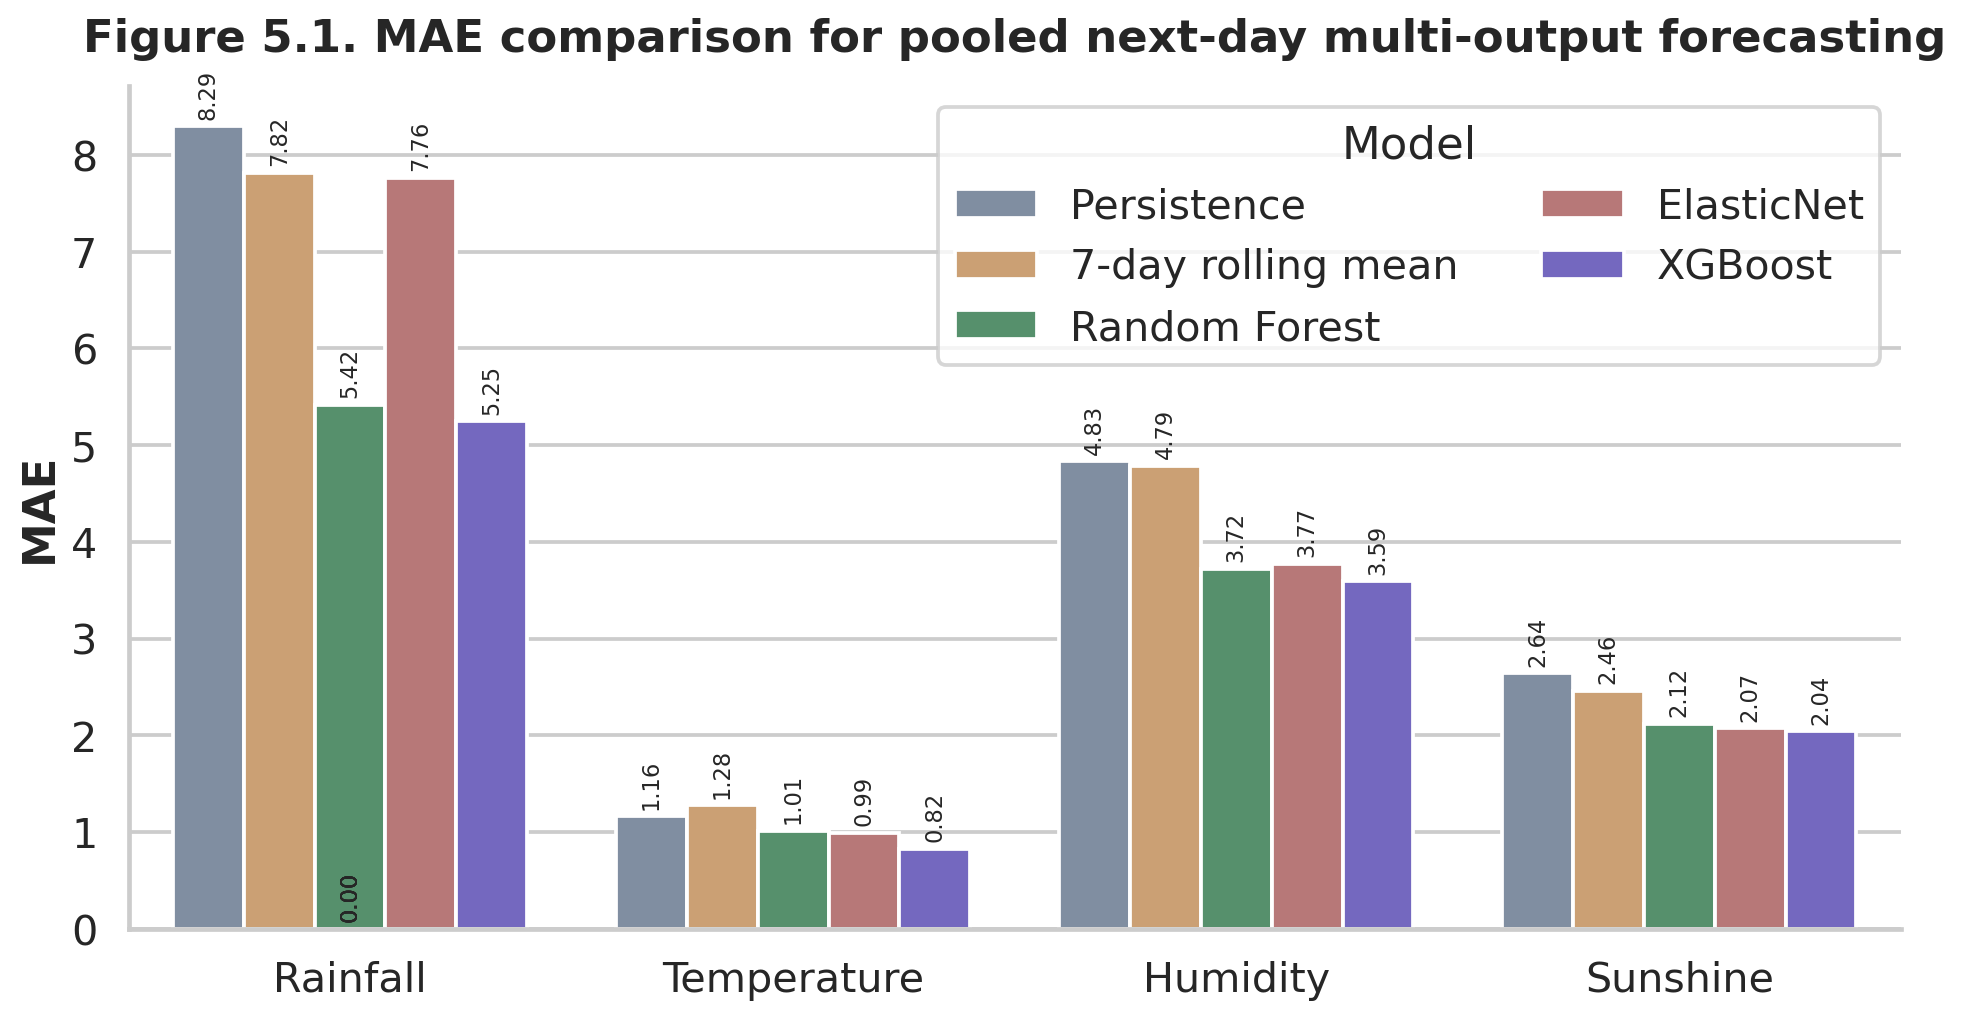

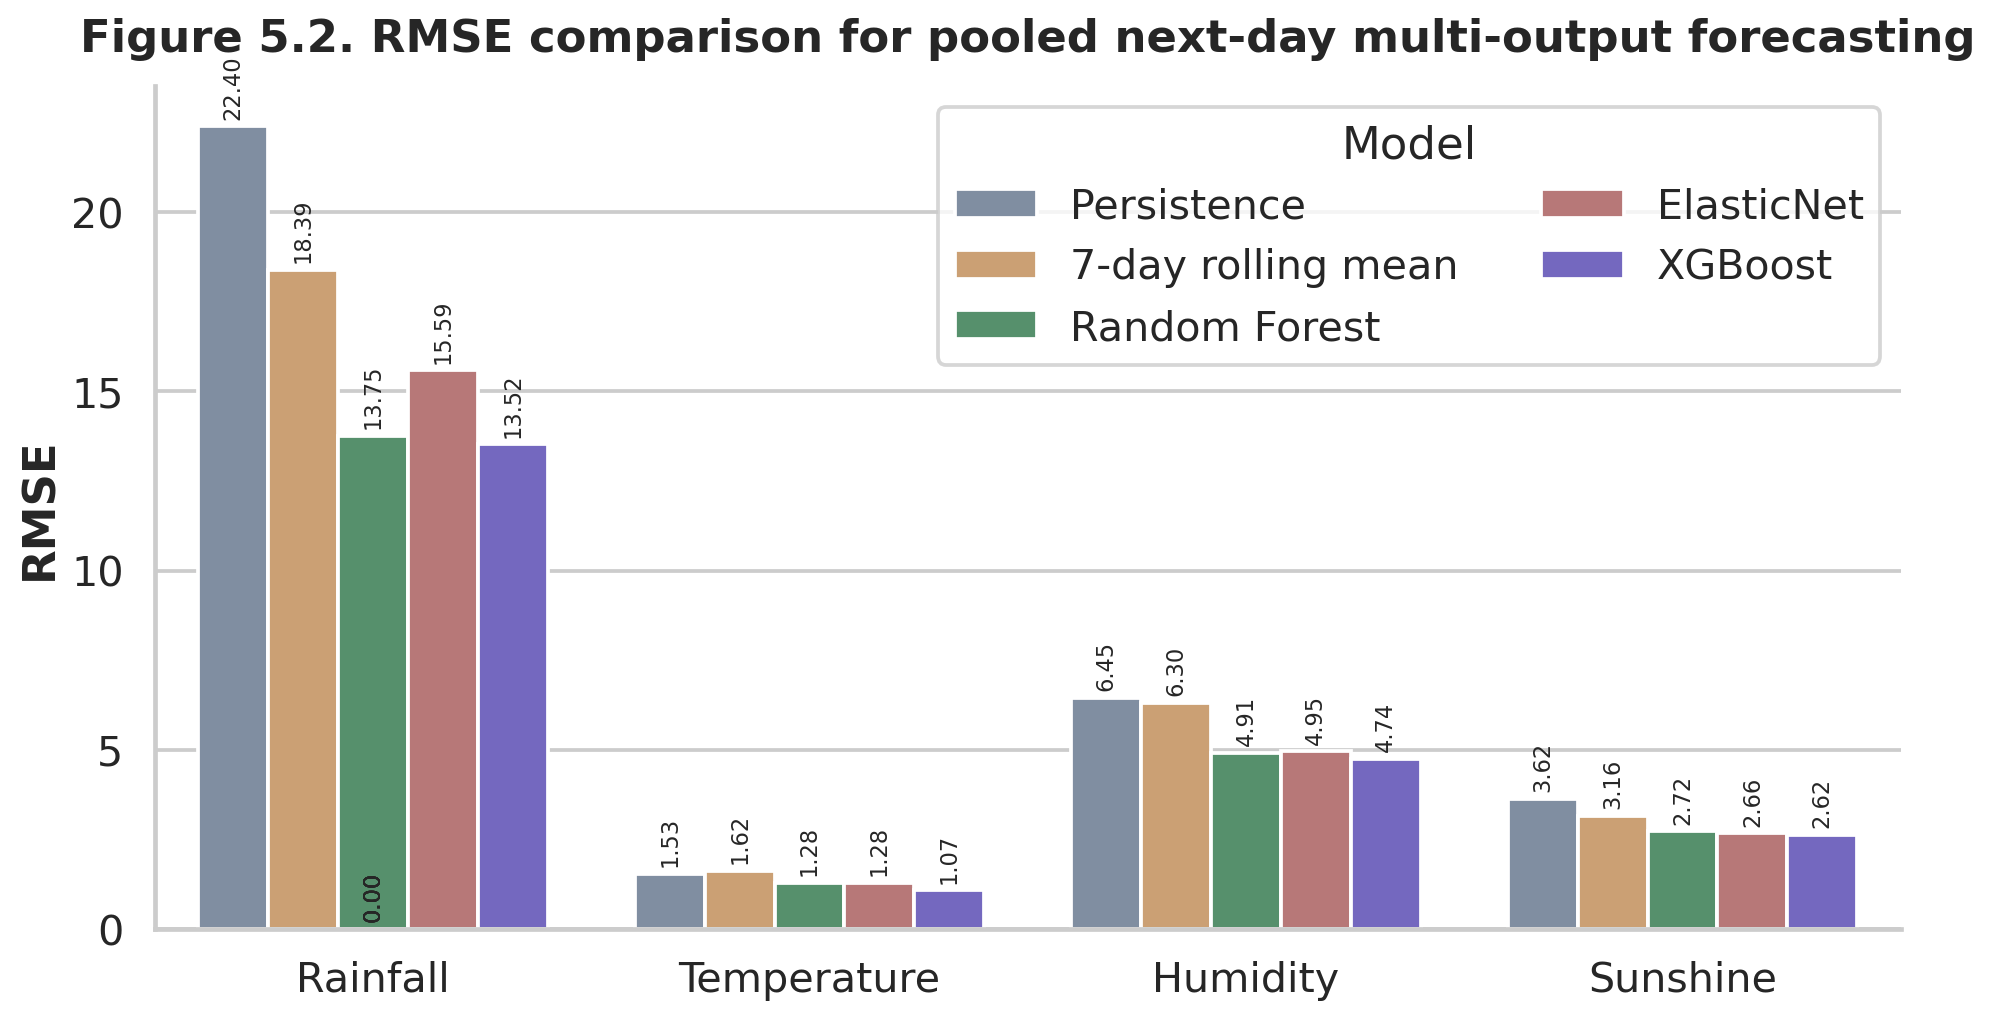

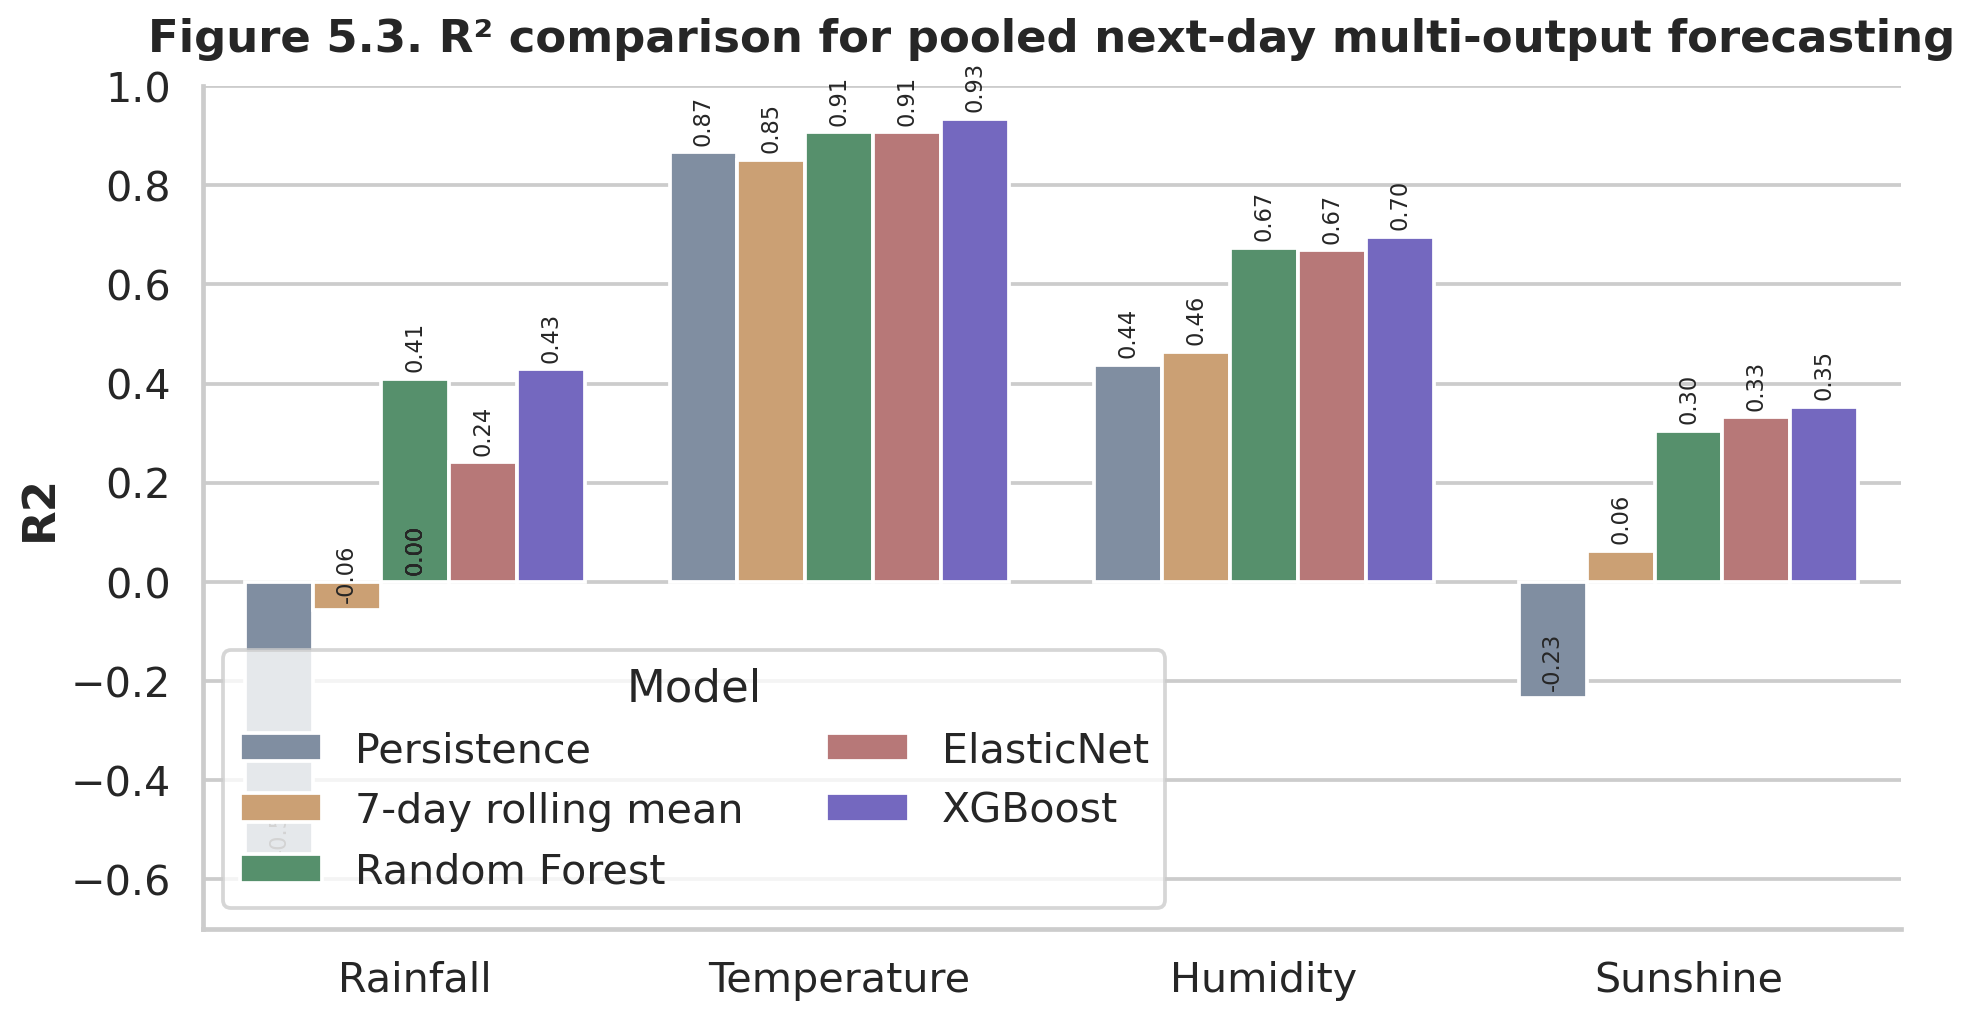

In [13]:
plot_metric_bars(
    pooled_reg,
    metric="MAE",
    title="Figure 5.1. MAE comparison for pooled next-day multi-output forecasting",
    save_name="Figure_5_1_MAE_pooled.png"
)
plot_metric_bars(
    pooled_reg,
    metric="RMSE",
    title="Figure 5.2. RMSE comparison for pooled next-day multi-output forecasting",
    save_name="Figure_5_2_RMSE_pooled.png"
)
plot_metric_bars(
    pooled_reg,
    metric="R2",
    title="Figure 5.3. R² comparison for pooled next-day multi-output forecasting",
    save_name="Figure_5_3_R2_pooled.png",
    ylim=(-0.7, 1.0)
)

## Step 8 — Heatmaps

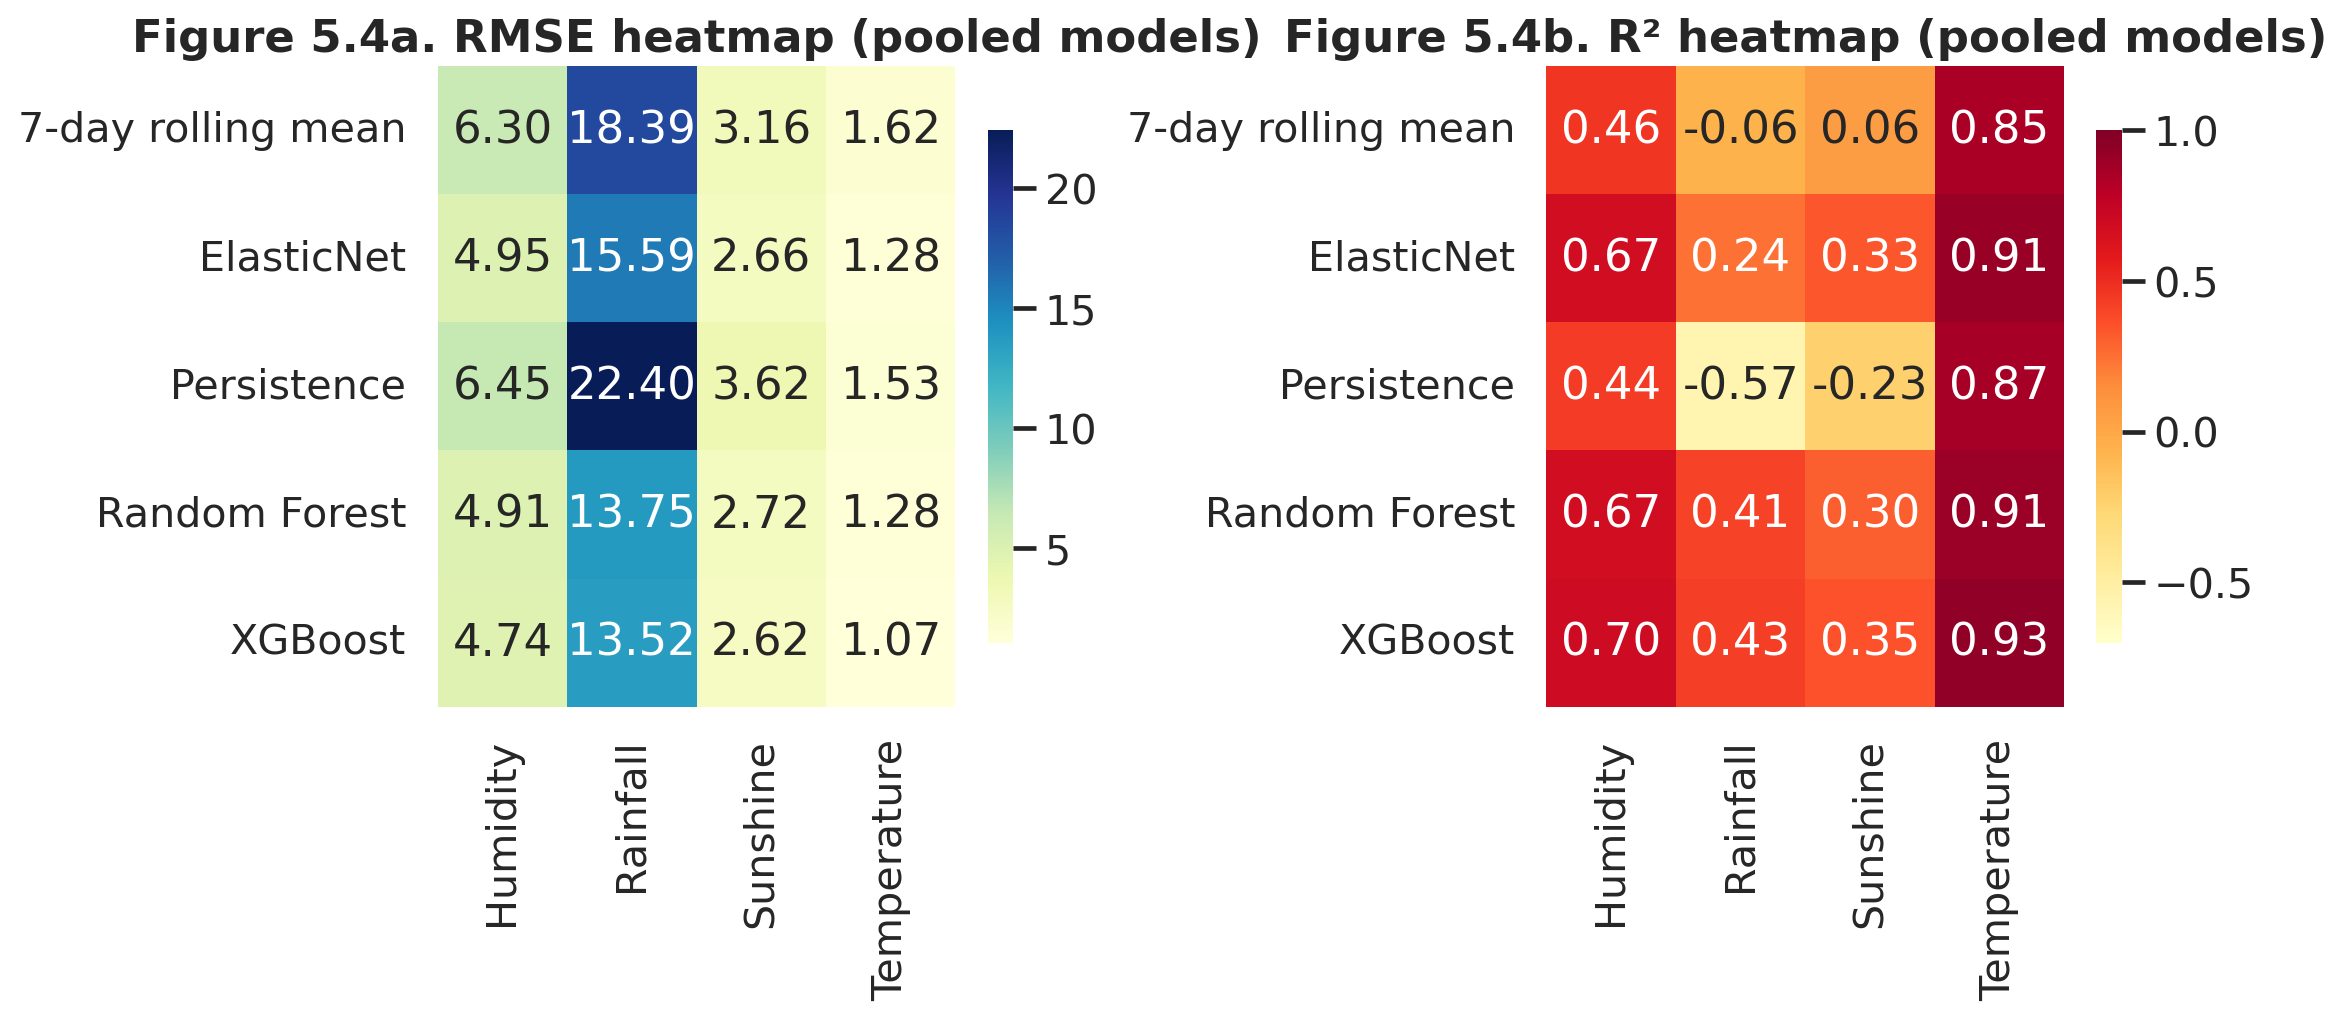

In [14]:
heat_rmse = pooled_reg.pivot(index="Model", columns="Target", values="RMSE")
heat_r2   = pooled_reg.pivot(index="Model", columns="Target", values="R2")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
sns.heatmap(heat_rmse, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title("Figure 5.4a. RMSE heatmap (pooled models)")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
sns.heatmap(heat_r2, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1], cbar_kws={"shrink": 0.8}, vmin=-0.7, vmax=1.0)
axes[1].set_title("Figure 5.4b. R² heatmap (pooled models)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(OUT_FIG / "Figure_5_4_heatmaps_pooled.png", bbox_inches="tight")
plt.show()

## Step 9 — Confusion matrix and classification metrics

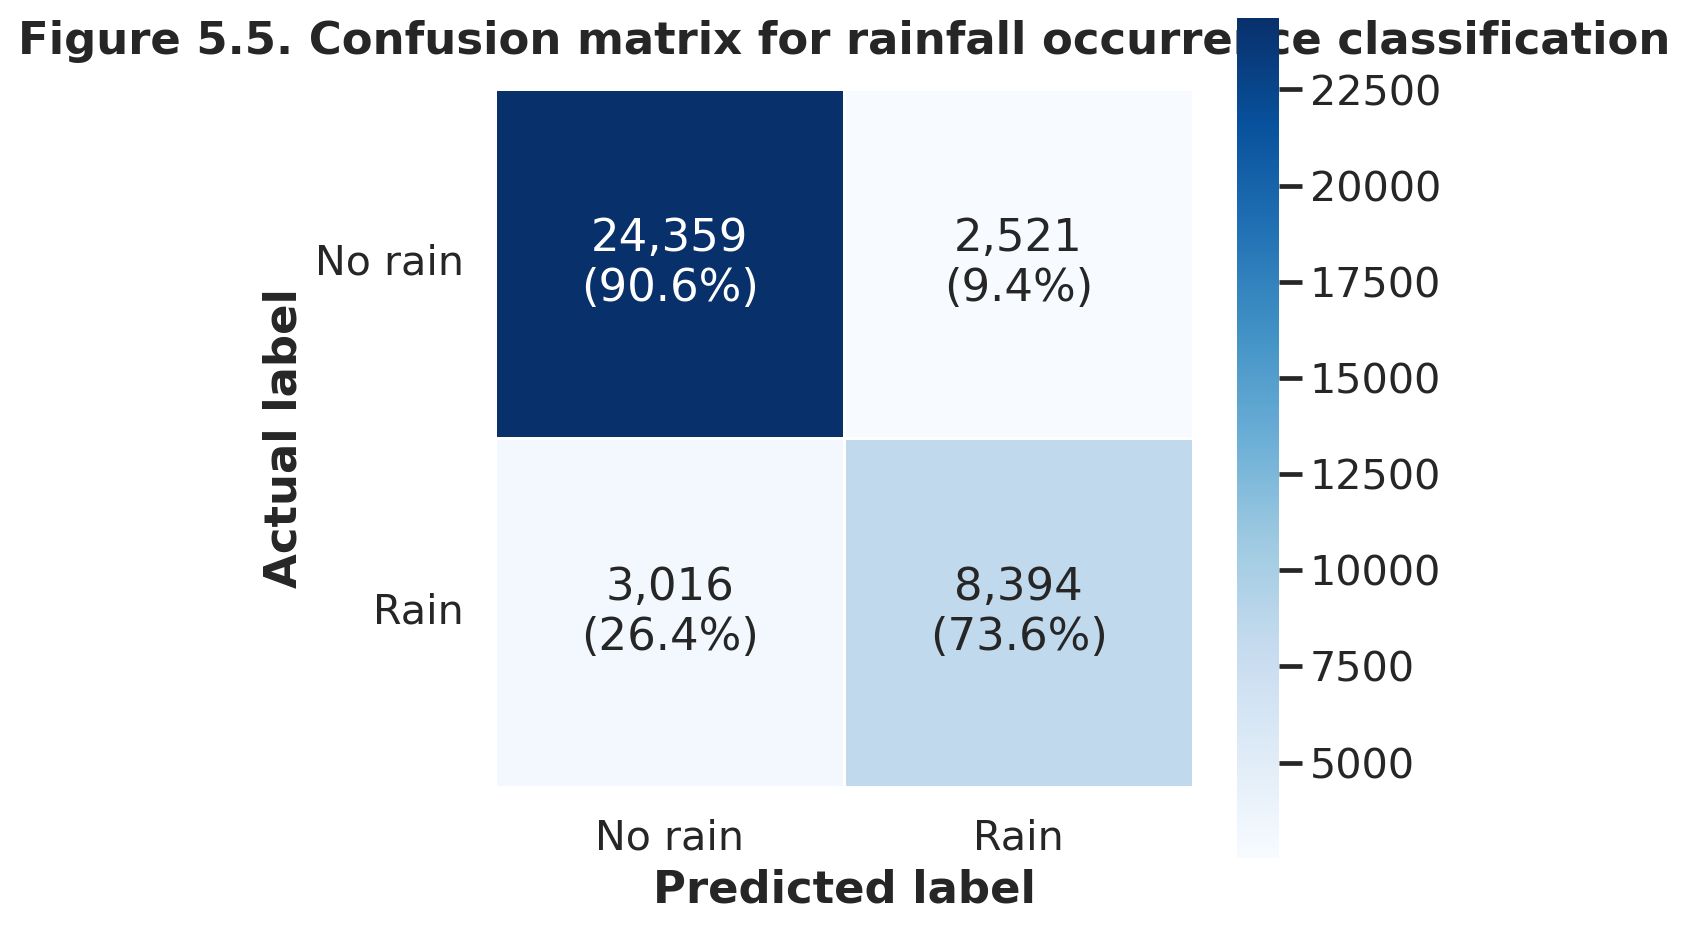

In [15]:
cm = np.array([[24359, 2521],
               [3016, 8394]])

cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
annot = np.empty_like(cm).astype(object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]:,}\n({cm_pct[i, j]:.1f}%)"

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=True, square=True,
            linewidths=1, linecolor="white", ax=ax)
ax.set_title("Figure 5.5. Confusion matrix for rainfall occurrence classification", pad=14)
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
ax.set_xticklabels(["No rain", "Rain"])
ax.set_yticklabels(["No rain", "Rain"], rotation=0)
plt.tight_layout()
plt.savefig(OUT_FIG / "Figure_5_5_confusion_matrix_publish.png", bbox_inches="tight")
plt.show()

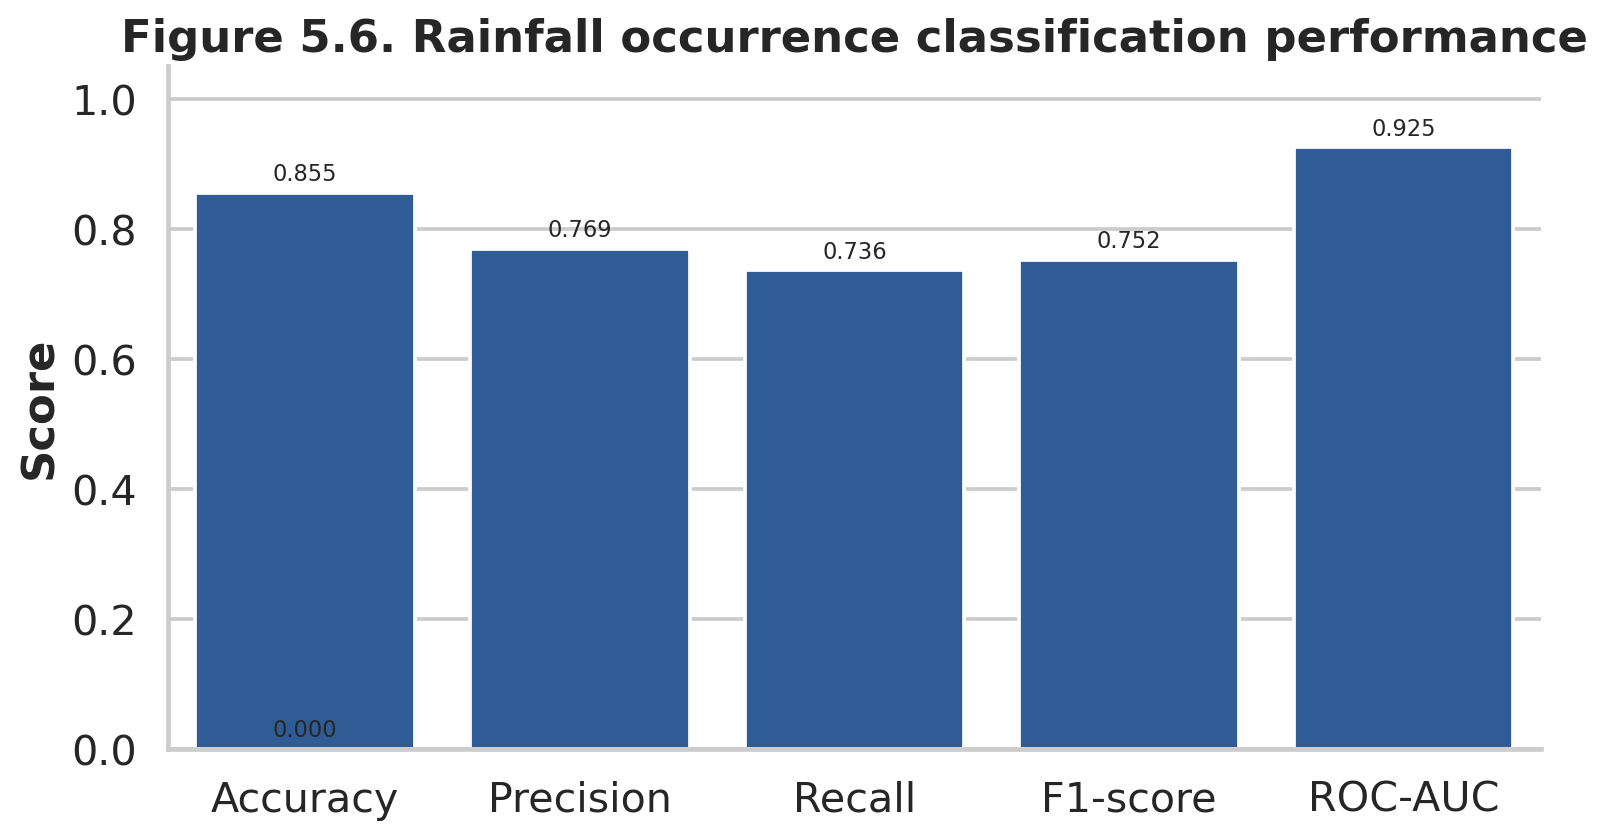

In [16]:
cls_long = cls_table.melt(id_vars="Model", var_name="Metric", value_name="Score")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=cls_long, x="Metric", y="Score", hue="Model", palette=["#1F5AA6"], ax=ax)
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.3f}",
                (p.get_x() + p.get_width()/2, h),
                ha="center", va="bottom", fontsize=9,
                xytext=(0, 3), textcoords="offset points")
ax.set_title("Figure 5.6. Rainfall occurrence classification performance")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.legend_.remove()
plt.tight_layout()
plt.savefig(OUT_FIG / "Figure_5_6_classification_metrics.png", bbox_inches="tight")
plt.show()

## Step 10 — Random Forest feature importance

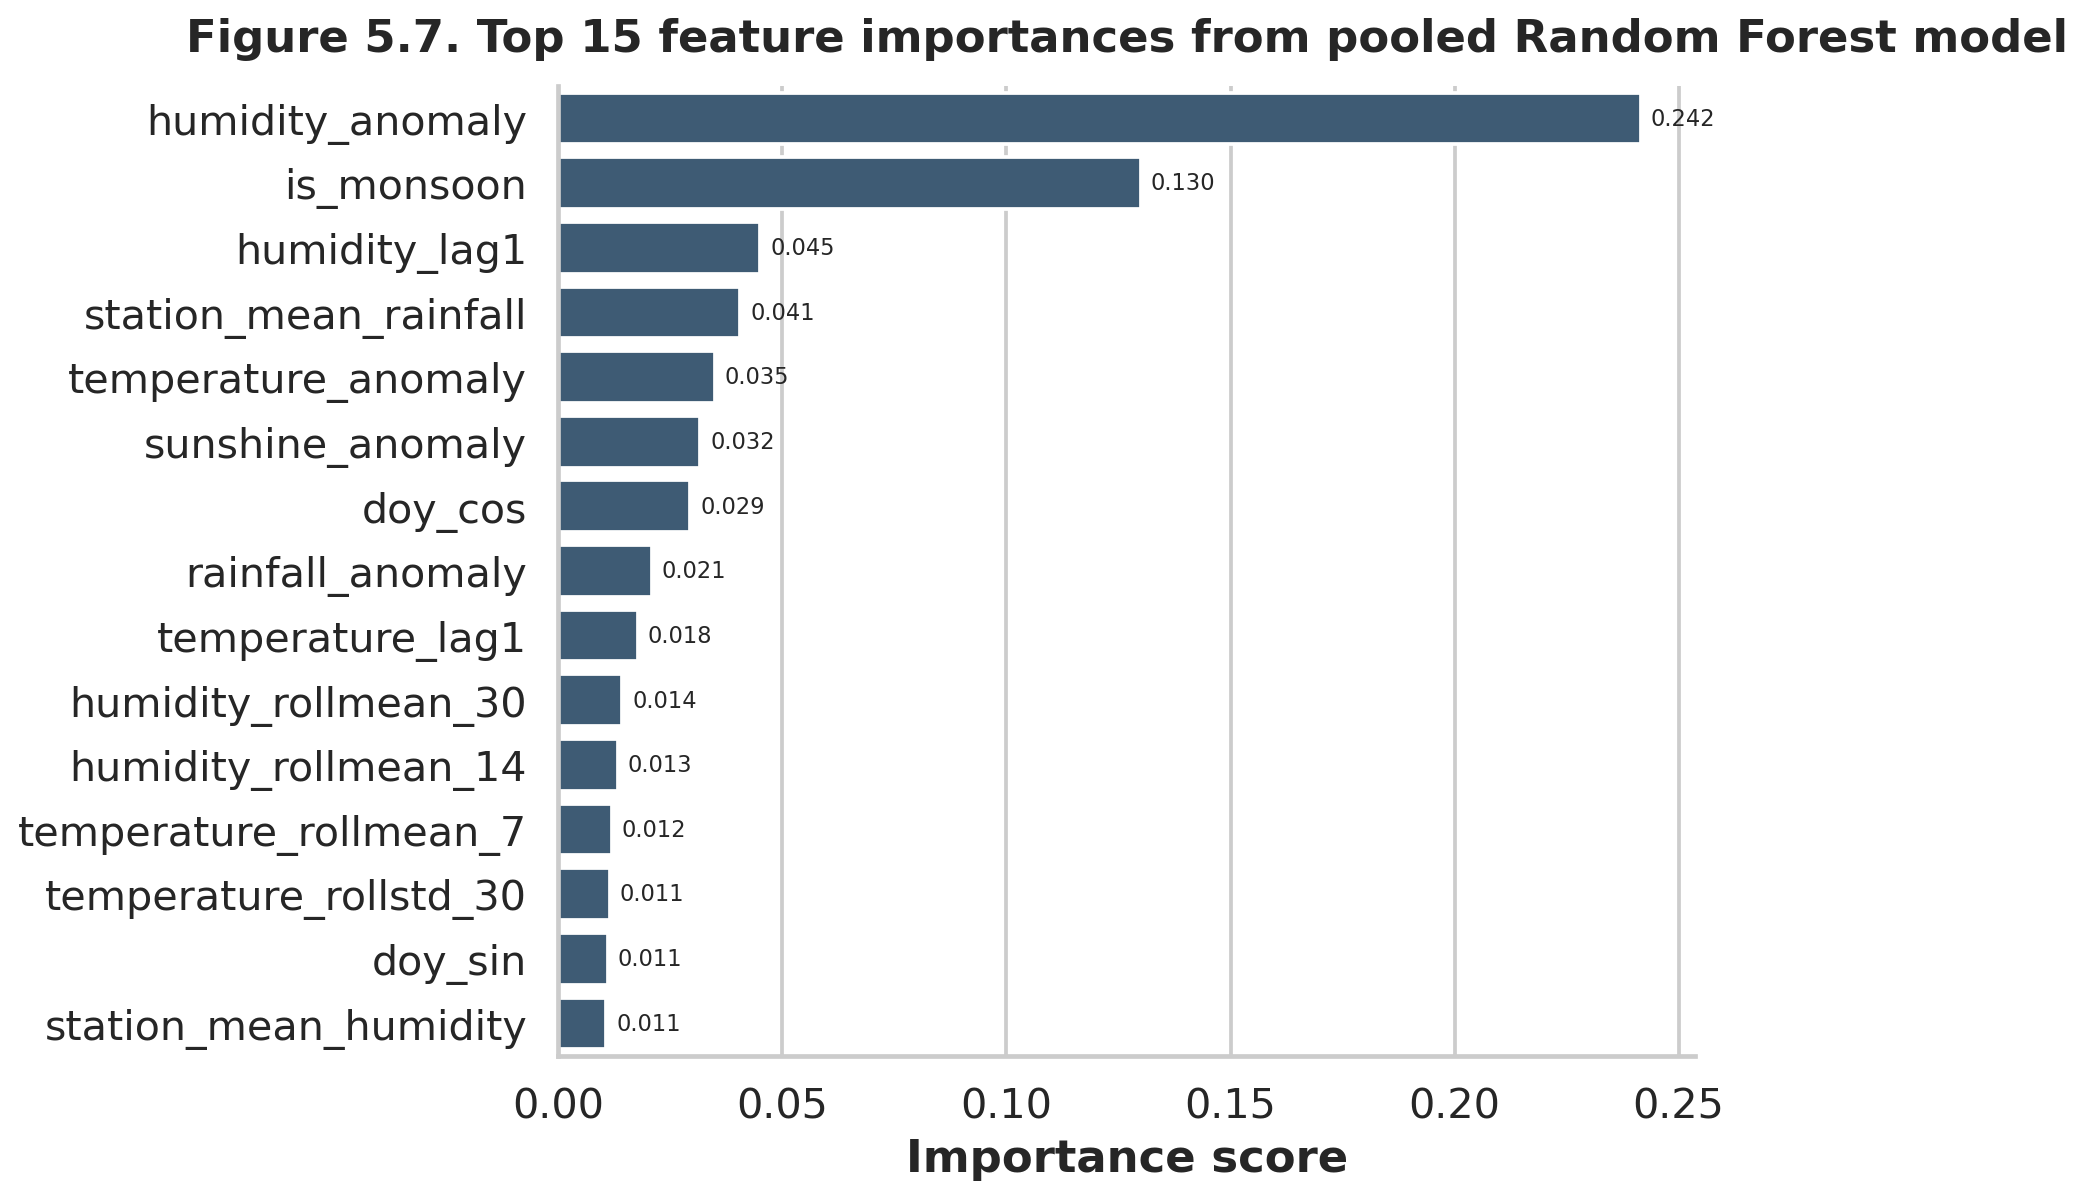

In [17]:
rf_imp_clean = rf_imp.copy().sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=rf_imp_clean, x="importance", y="feature", color="#355C7D", ax=ax)
for p in ax.patches:
    w = p.get_width()
    ax.annotate(f"{w:.3f}",
                (w, p.get_y() + p.get_height()/2),
                ha="left", va="center", fontsize=9,
                xytext=(4, 0), textcoords="offset points")
ax.set_title("Figure 5.7. Top 15 feature importances from pooled Random Forest model", pad=14)
ax.set_xlabel("Importance score")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUT_FIG / "Figure_5_7_rf_feature_importance_publish.png", bbox_inches="tight")
plt.show()

## Step 11 — Bi-LSTM history and Dhaka-only result plots

In [18]:
if Path("bilstm_history_dhaka.png").exists():
    img = plt.imread("bilstm_history_dhaka.png")
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Figure 5.8. Bi-LSTM training history for Dhaka station")
    plt.show()
else:
    print("bilstm_history_dhaka.png not found. If needed, regenerate it from your training history.")

bilstm_history_dhaka.png not found. If needed, regenerate it from your training history.


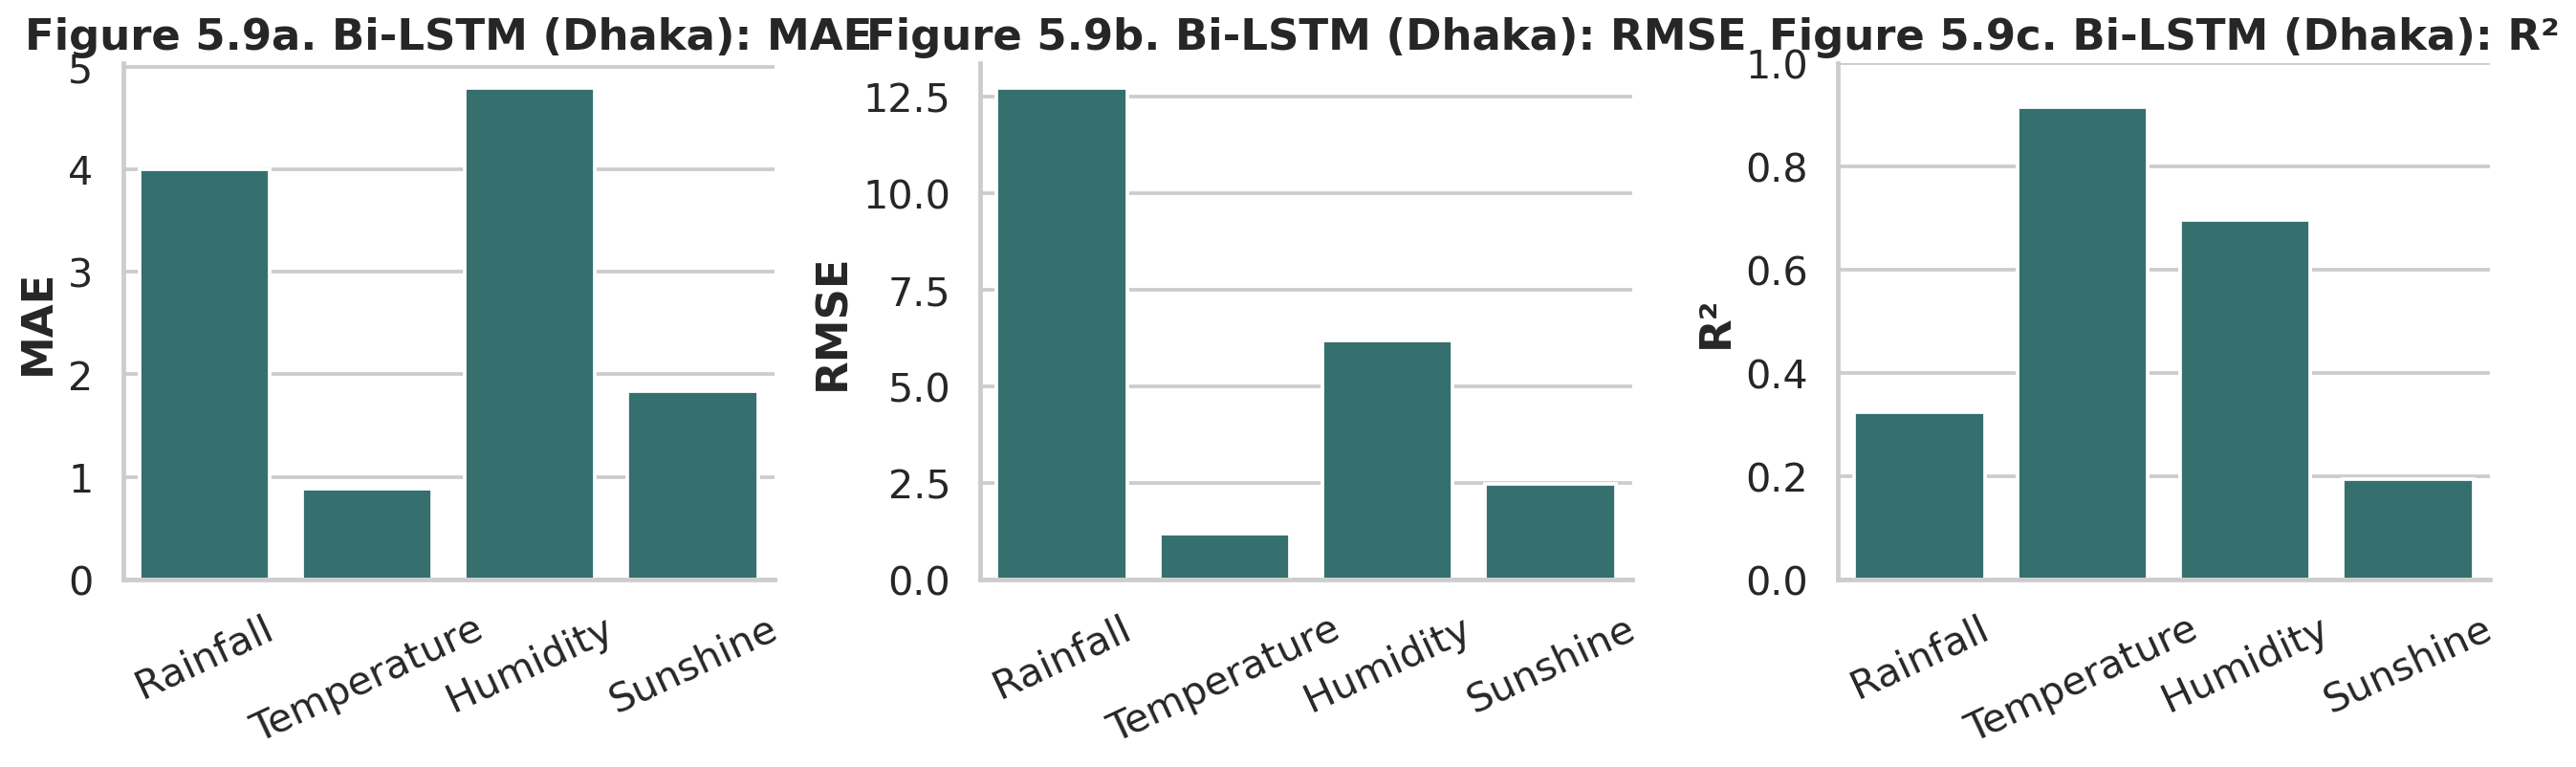

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
sns.barplot(data=bilstm_table, x="Target", y="MAE", color="#2B7A78", ax=axes[0])
axes[0].set_title("Figure 5.9a. Bi-LSTM (Dhaka): MAE")
axes[0].set_xlabel("")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=25)
sns.barplot(data=bilstm_table, x="Target", y="RMSE", color="#2B7A78", ax=axes[1])
axes[1].set_title("Figure 5.9b. Bi-LSTM (Dhaka): RMSE")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=25)
sns.barplot(data=bilstm_table, x="Target", y="R2", color="#2B7A78", ax=axes[2])
axes[2].set_title("Figure 5.9c. Bi-LSTM (Dhaka): R²")
axes[2].set_xlabel("")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=25)
axes[2].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUT_FIG / "Figure_5_9_bilstm_dhaka_metrics.png", bbox_inches="tight")
plt.show()

## Step 12 — Best pooled model figure

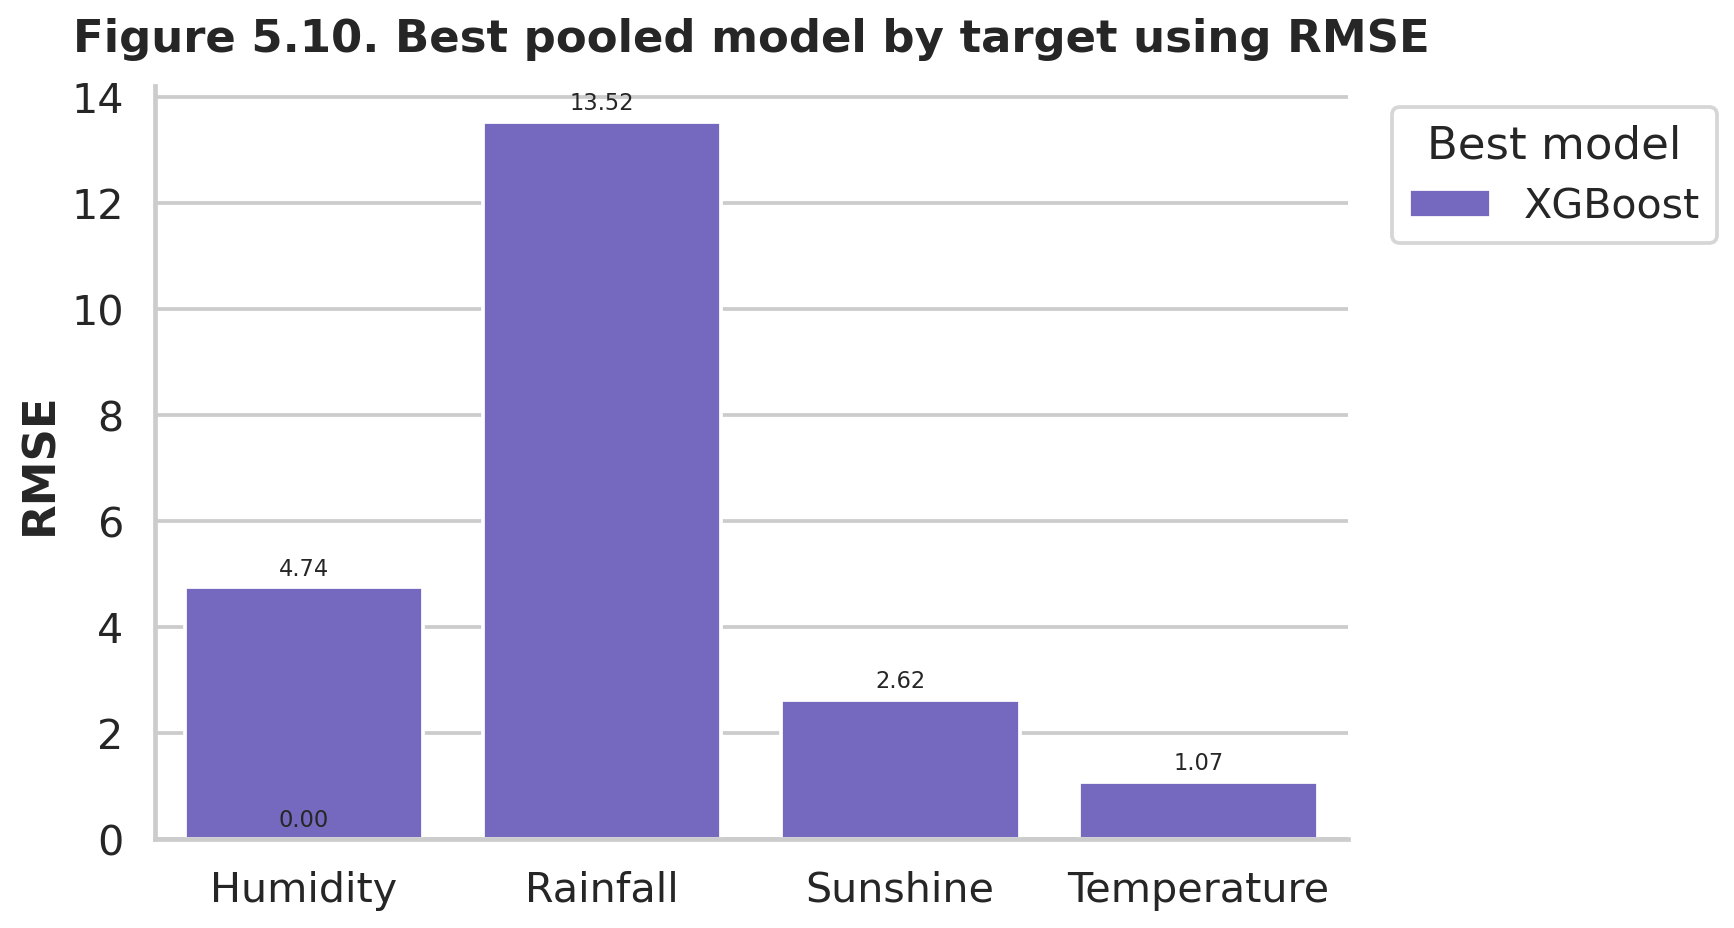

In [20]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=best_pooled_by_rmse,
    x="Target", y="RMSE", hue="Model",
    dodge=False, palette=palette_models, ax=ax
)
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.2f}",
                (p.get_x() + p.get_width()/2, h),
                ha="center", va="bottom", fontsize=9,
                xytext=(0, 3), textcoords="offset points")
ax.set_title("Figure 5.10. Best pooled model by target using RMSE", pad=14)
ax.set_xlabel("")
ax.set_ylabel("RMSE")
ax.legend(title="Best model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUT_FIG / "Figure_5_10_best_model_by_target.png", bbox_inches="tight")
plt.show()

## Step 13 — Appendix pivot tables

In [21]:
pivot_rmse = pooled_reg.pivot(index="Target", columns="Model", values="RMSE").round(3)
pivot_mae  = pooled_reg.pivot(index="Target", columns="Model", values="MAE").round(3)
pivot_r2   = pooled_reg.pivot(index="Target", columns="Model", values="R2").round(3)

pivot_rmse.to_csv(OUT_TABLE / "Appendix_RMSE_pivot.csv")
pivot_mae.to_csv(OUT_TABLE / "Appendix_MAE_pivot.csv")
pivot_r2.to_csv(OUT_TABLE / "Appendix_R2_pivot.csv")
pivot_rmse

Model,7-day rolling mean,ElasticNet,Persistence,Random Forest,XGBoost
Target,,,,,
Humidity,6.299,4.952,6.451,4.914,4.741
Rainfall,18.393,15.588,22.399,13.751,13.524
Sunshine,3.156,2.664,3.621,2.719,2.620
Temperature,1.621,1.280,1.534,1.283,1.074


## Step 14 — Optional export table figures as PNG

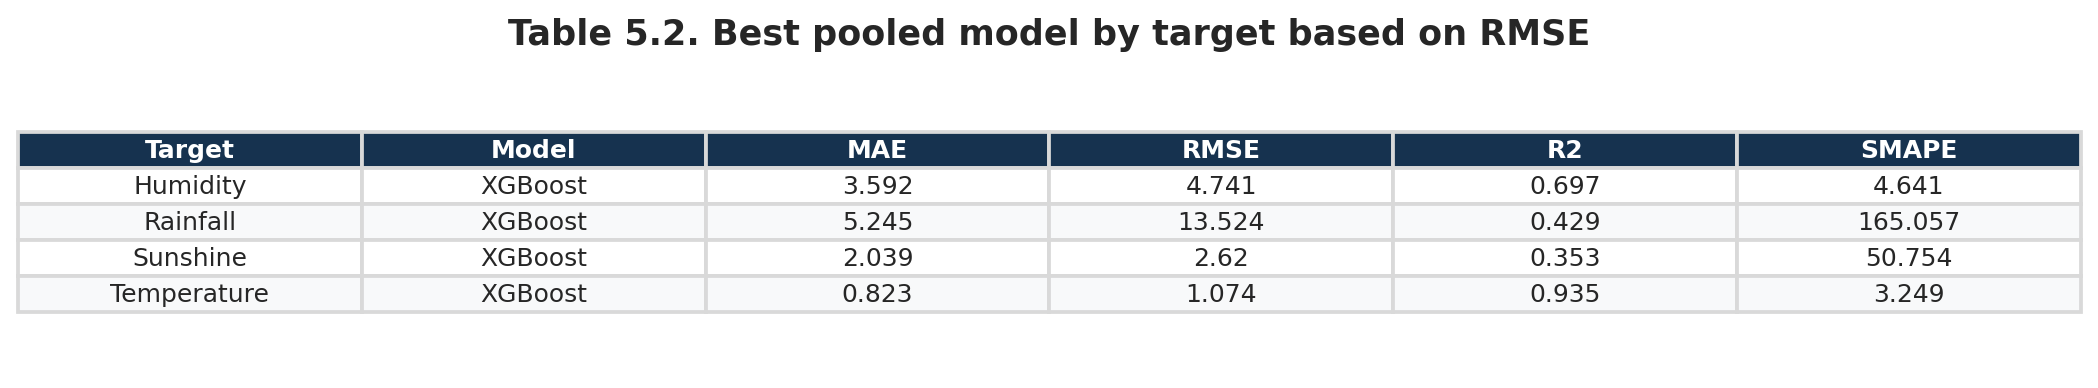

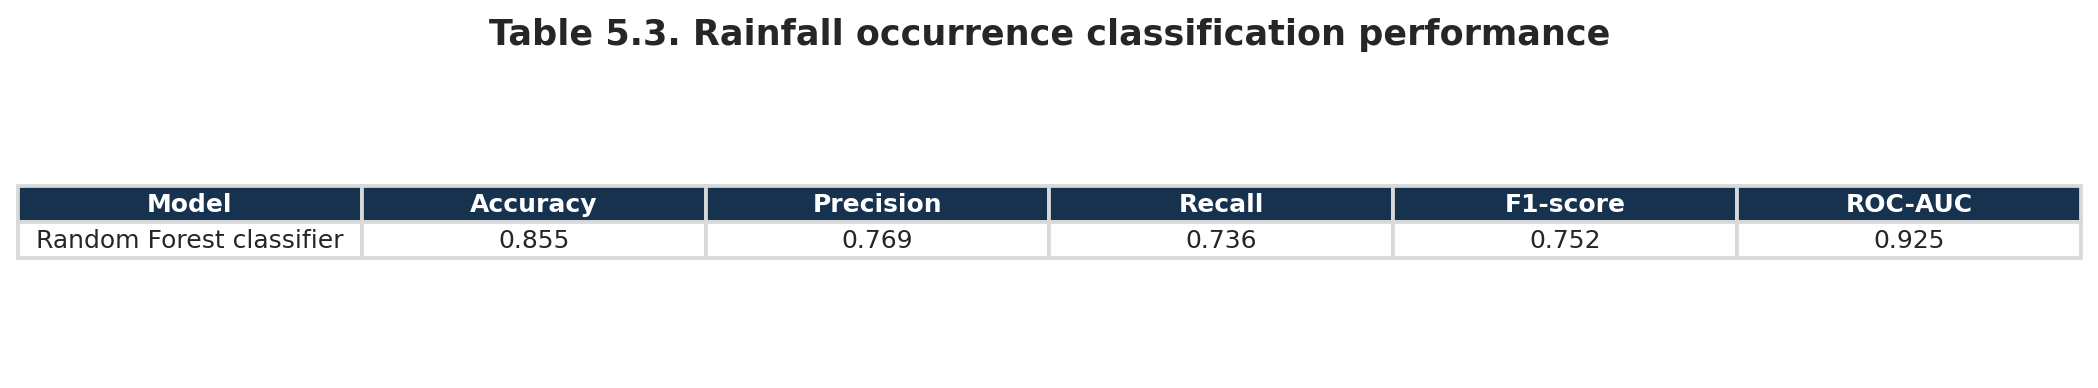

In [22]:
def dataframe_to_figure(df, title, save_name, col_width=2.0, row_height=0.45, fontsize=10):
    fig_width = max(8, len(df.columns) * col_width)
    fig_height = max(2.5, (len(df) + 1) * row_height)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    table = ax.table(cellText=df.values, colLabels=df.columns, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.4)
    for (r, c), cell in table.get_celld().items():
        if r == 0:
            cell.set_text_props(weight="bold", color="white")
            cell.set_facecolor("#16324F")
        else:
            cell.set_facecolor("#F8F9FA" if r % 2 == 0 else "white")
        cell.set_edgecolor("#D9D9D9")
    plt.tight_layout()
    plt.savefig(OUT_FIG / save_name, bbox_inches="tight")
    plt.show()

dataframe_to_figure(
    best_pooled_by_rmse,
    "Table 5.2. Best pooled model by target based on RMSE",
    "Table_5_2_best_model_by_target.png"
)
dataframe_to_figure(
    cls_table,
    "Table 5.3. Rainfall occurrence classification performance",
    "Table_5_3_classification_results.png"
)